# EDA — Airline Passenger Satisfaction

## 1. Carga de datos

In [22]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, chi2_contingency

sns.set_style('whitegrid')

path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
df_train = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))
df = pd.concat([df_train, df_test], ignore_index=True)

print(df.shape)
df.head()

(129880, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Limpieza inicial

In [23]:
print(df.info())
print("\nColumnas:", list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      1298

In [24]:
print(df['Unnamed: 0'].head(10))
print(df_train['Unnamed: 0'].equals(df_train.index.to_series()))
print(df_test['Unnamed: 0'].equals(df_test.index.to_series()))

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: Unnamed: 0, dtype: int64
True
True


In [25]:
df = df.drop(columns=['Unnamed: 0'])
print(df.shape)

(129880, 24)


## 3. Valores faltantes

In [26]:
faltantes = df.isnull().sum()
faltantes_pct = (faltantes / len(df) * 100).round(2)
resumen_faltantes = pd.DataFrame({'faltantes': faltantes, 'porcentaje': faltantes_pct})
print(resumen_faltantes[resumen_faltantes['faltantes'] > 0])

                          faltantes  porcentaje
Arrival Delay in Minutes        393         0.3


In [27]:
print("Media:", df['Arrival Delay in Minutes'].mean())
print("Mediana:", df['Arrival Delay in Minutes'].median())
print("% de vuelos sin demora de llegada:", (df['Arrival Delay in Minutes'] == 0).mean() * 100)

Media: 15.09112883918849
Mediana: 0.0
% de vuelos sin demora de llegada: 56.015552817985835


In [28]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
print("Faltantes restantes:", df.isnull().sum().sum())

Faltantes restantes: 0


### Faltantes ocultos: los ceros en las calificaciones

In [29]:
calificaciones = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                  'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                  'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling',
                  'Checkin service', 'Inflight service', 'Cleanliness']

ceros = (df[calificaciones] == 0).sum()
ceros_pct = (ceros / len(df) * 100).round(2)
resumen_ceros = pd.DataFrame({'ceros': ceros, 'porcentaje': ceros_pct}).sort_values('ceros', ascending=False)
print(resumen_ceros)
print("\nFilas con al menos un 0:", (df[calificaciones] == 0).any(axis=1).sum())

                                   ceros  porcentaje
Departure/Arrival time convenient   6681        5.14
Ease of Online booking              5682        4.37
Inflight wifi service               3916        3.02
Online boarding                     3080        2.37
Leg room service                     598        0.46
Food and drink                       132        0.10
Inflight entertainment                18        0.01
Cleanliness                           14        0.01
Inflight service                       5        0.00
On-board service                       5        0.00
Gate location                          1        0.00
Seat comfort                           1        0.00
Checkin service                        1        0.00
Baggage handling                       0        0.00

Filas con al menos un 0: 10313


In [30]:
print(f"% satisfechos en todo el dataset: {(df['satisfaction'] == 'satisfied').mean() * 100:.1f}%\n")
for col in resumen_ceros[resumen_ceros['ceros'] > 100].index:
    pct_sat = (df.loc[df[col] == 0, 'satisfaction'] == 'satisfied').mean() * 100
    print(f"{col}: {pct_sat:.1f}% satisfechos entre los que respondieron 0")

% satisfechos en todo el dataset: 43.4%

Departure/Arrival time convenient: 48.1% satisfechos entre los que respondieron 0
Ease of Online booking: 66.6% satisfechos entre los que respondieron 0
Inflight wifi service: 99.7% satisfechos entre los que respondieron 0
Online boarding: 56.5% satisfechos entre los que respondieron 0
Leg room service: 34.4% satisfechos entre los que respondieron 0
Food and drink: 41.7% satisfechos entre los que respondieron 0


### Duplicados

In [31]:
print("Filas duplicadas:", df.duplicated().sum())
print("IDs repetidos:", df['id'].duplicated().sum())
print("Filas duplicadas sin contar el id:", df.drop(columns='id').duplicated().sum())

Filas duplicadas: 0
IDs repetidos: 0
Filas duplicadas sin contar el id: 0


## 4. Outliers

In [32]:
todas_columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()
print(todas_columnas_numericas)

['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [33]:
df[todas_columnas_numericas].describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.045465
std,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.416353
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


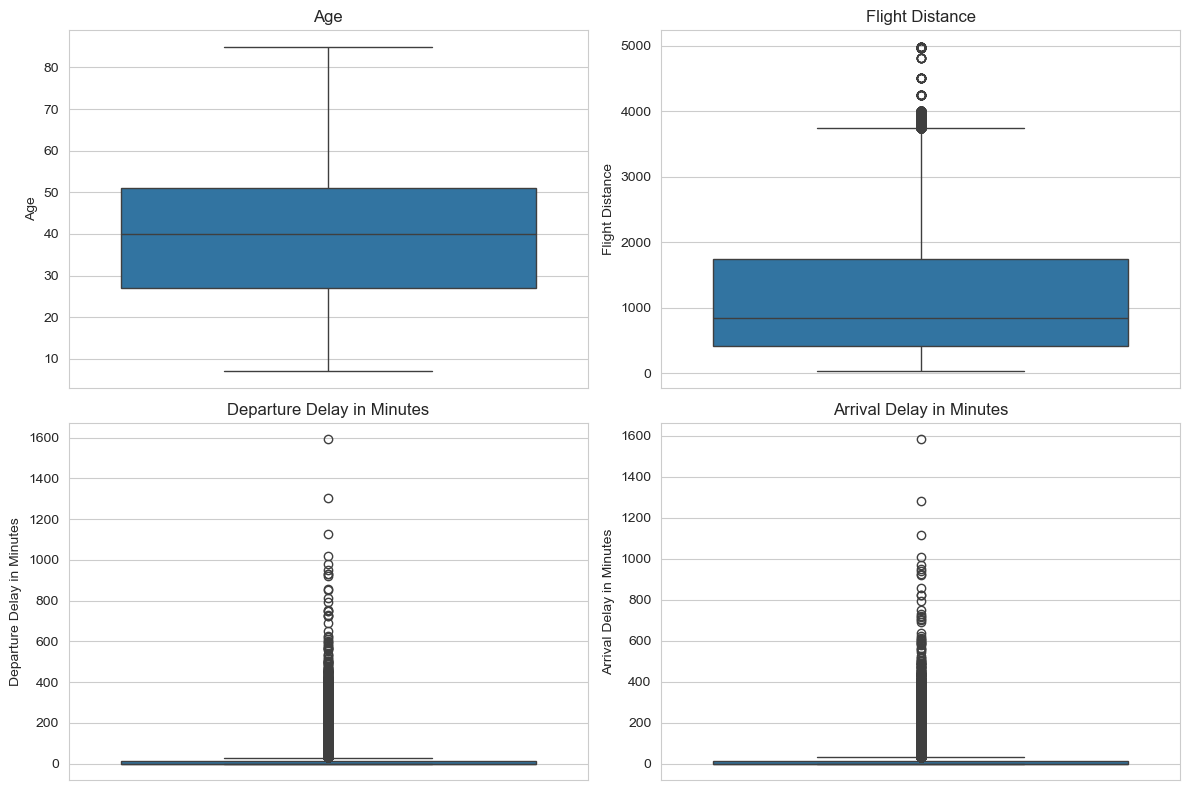

In [34]:
columnas_numericas = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), columnas_numericas):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [35]:
def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = (serie < lim_inf) | (serie > lim_sup)
    return outliers.sum(), lim_inf, lim_sup

for col in columnas_numericas:
    n_outliers, li, ls = detectar_outliers_iqr(df[col])
    pct = (n_outliers / len(df)) * 100
    print(f"{col}: {n_outliers} outliers ({pct:.2f}%) — rango válido [{li:.1f}, {ls:.1f}]")

Age: 0 outliers (0.00%) — rango válido [-9.0, 87.0]
Flight Distance: 2855 outliers (2.20%) — rango válido [-1581.0, 3739.0]
Departure Delay in Minutes: 18098 outliers (13.93%) — rango válido [-18.0, 30.0]
Arrival Delay in Minutes: 17492 outliers (13.47%) — rango válido [-19.5, 32.5]


### Comparación con z-score

In [36]:
comparacion = []
for col in columnas_numericas:
    z = np.abs(stats.zscore(df[col]))
    n_iqr, _, _ = detectar_outliers_iqr(df[col])
    comparacion.append({
        'columna': col,
        'outliers_IQR': n_iqr,
        'outliers_z>3': (z > 3).sum(),
        '%_IQR': round(n_iqr / len(df) * 100, 2),
        '%_z>3': round((z > 3).sum() / len(df) * 100, 2),
        'limite_z (media + 3*std)': round(df[col].mean() + 3 * df[col].std(), 1),
    })
pd.DataFrame(comparacion).set_index('columna')

,outliers_IQR,outliers_z>3,%_IQR,%_z>3,limite_z (media + 3*std)
columna,,,,,
Age,0,25,0.00,0.02,84.8
Flight Distance,2855,78,2.20,0.06,4182.7
Departure Delay in Minutes,18098,2748,13.93,2.12,128.9
Arrival Delay in Minutes,17492,2742,13.47,2.11,130.3


### Diagramas de dispersión

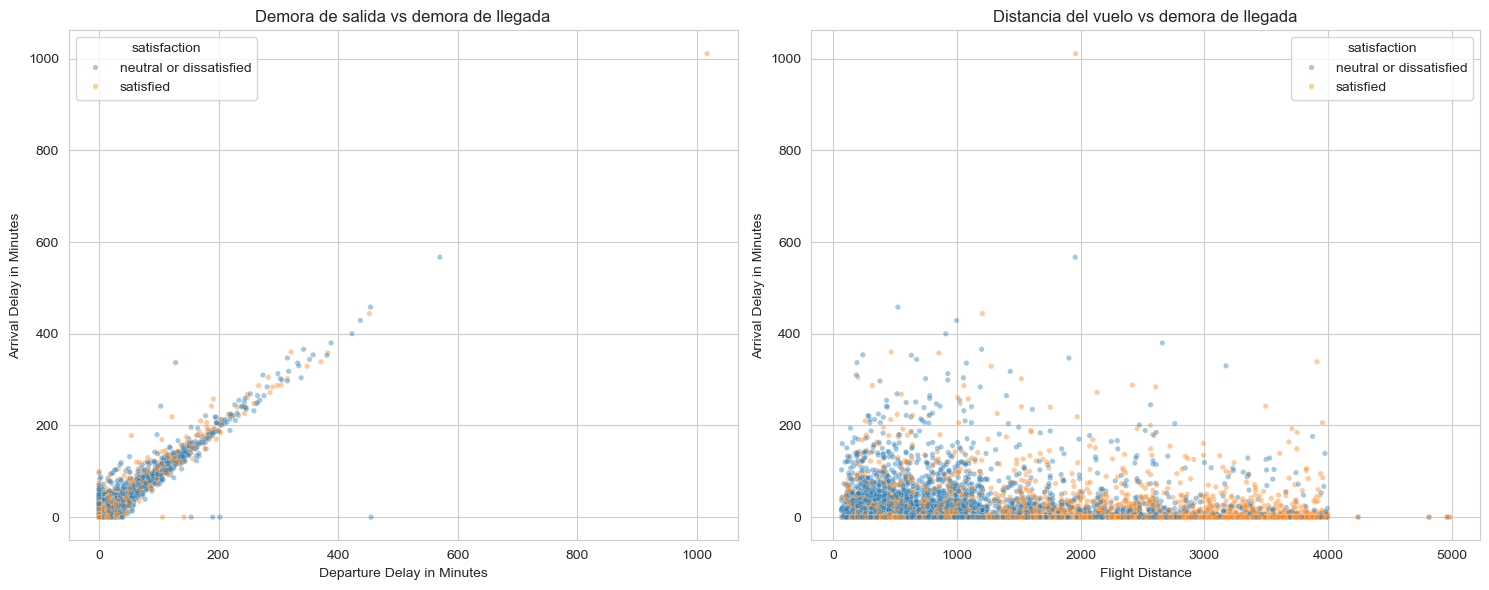

In [37]:
muestra = df.sample(10000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=muestra, x='Departure Delay in Minutes', y='Arrival Delay in Minutes',
                hue='satisfaction', alpha=0.4, s=15, ax=axes[0])
axes[0].set_title('Demora de salida vs demora de llegada')

sns.scatterplot(data=muestra, x='Flight Distance', y='Arrival Delay in Minutes',
                hue='satisfaction', alpha=0.4, s=15, ax=axes[1])
axes[1].set_title('Distancia del vuelo vs demora de llegada')
plt.tight_layout()
plt.show()

In [38]:
imputados = df_train['Arrival Delay in Minutes'].isna().tolist() + df_test['Arrival Delay in Minutes'].isna().tolist()
imputados = pd.Series(imputados, index=df.index)

raros = (df['Departure Delay in Minutes'] > 60) & (df['Arrival Delay in Minutes'] == 0)
print("Vuelos con más de 60 min de demora de salida y 0 de llegada:", raros.sum())
print("De esos, cuántos eran faltantes imputados con la mediana:", (raros & imputados).sum())

Vuelos con más de 60 min de demora de salida y 0 de llegada: 86
De esos, cuántos eran faltantes imputados con la mediana: 86


## 5. Distribución de las variables numéricas

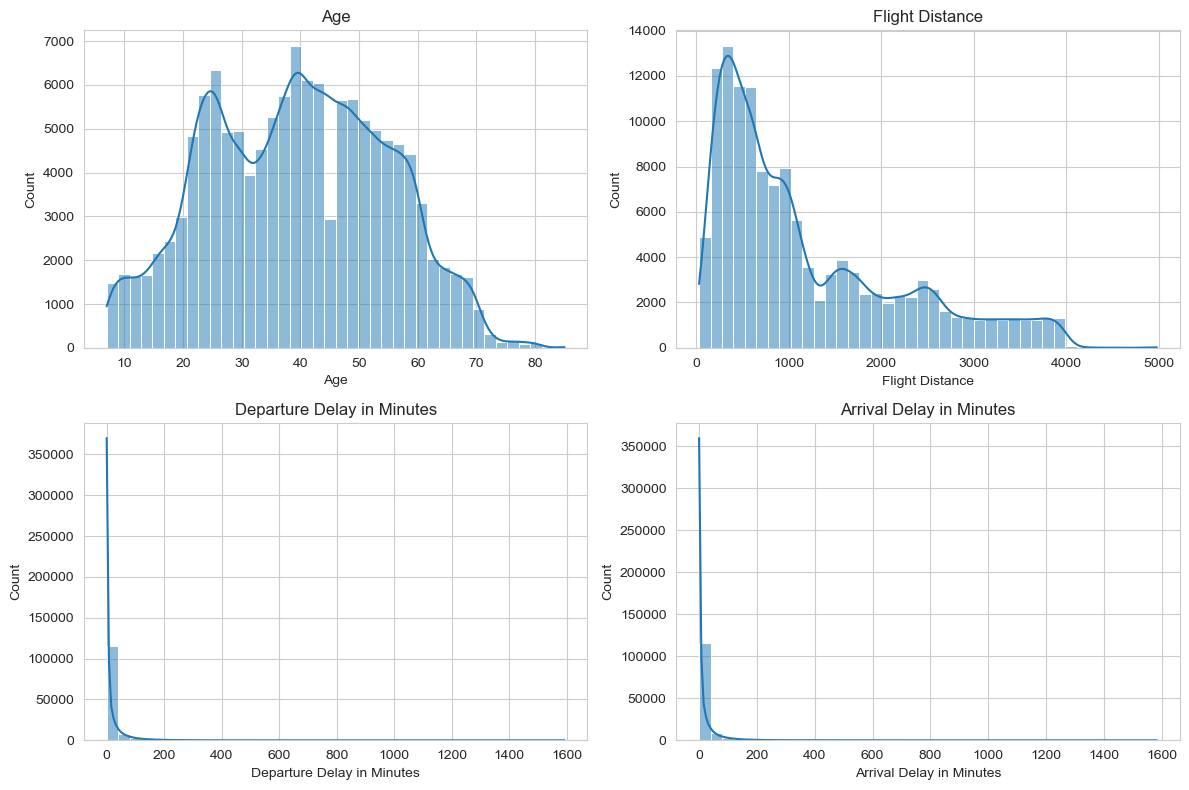

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), columnas_numericas):
    sns.histplot(df[col], kde=True, ax=ax, bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [40]:
for col in columnas_numericas:
    print(f"{col}: skewness = {df[col].skew():.2f}")

Age: skewness = -0.00
Flight Distance: skewness = 1.11
Departure Delay in Minutes: skewness = 6.82
Arrival Delay in Minutes: skewness = 6.68


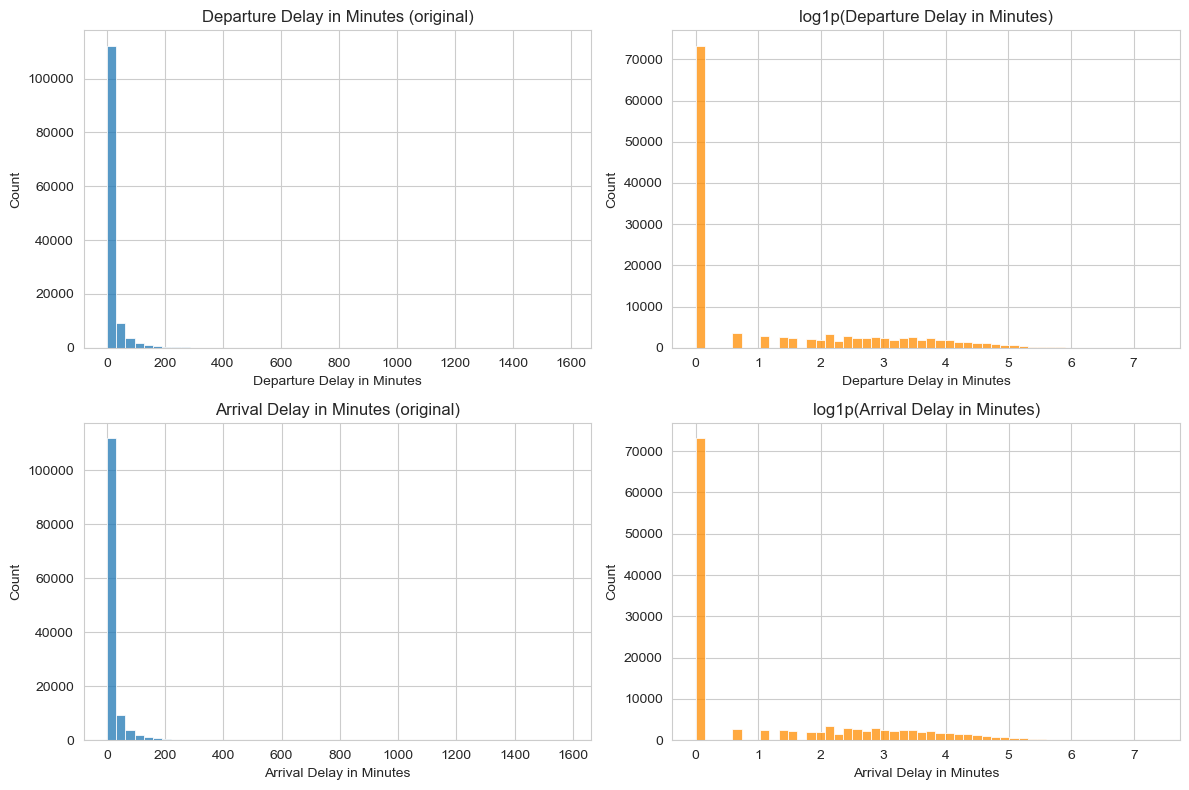

Departure Delay in Minutes: skewness original = 6.82 | con log1p = 0.92
Arrival Delay in Minutes: skewness original = 6.68 | con log1p = 0.88


In [41]:
delays = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for fila, col in enumerate(delays):
    sns.histplot(df[col], bins=50, ax=axes[fila, 0])
    axes[fila, 0].set_title(f"{col} (original)")
    sns.histplot(np.log1p(df[col]), bins=50, ax=axes[fila, 1], color='darkorange')
    axes[fila, 1].set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

for col in delays:
    print(f"{col}: skewness original = {df[col].skew():.2f} | con log1p = {np.log1p(df[col]).skew():.2f}")

## 6. Variables categóricas

In [44]:
columnas_categoricas = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

In [ ]:
for col in columnas_categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3) * 100)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), columnas_categoricas):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()

### Las 14 calificaciones de la encuesta

In [ ]:
calif_sin_ceros = df[calificaciones].replace(0, np.nan)

fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for ax, col in zip(axes.flatten(), calificaciones):
    conteo = df[col].value_counts().reindex(range(6), fill_value=0)
    colores = ['lightgray'] + ['steelblue'] * 5
    ax.bar(conteo.index, conteo.values, color=colores)
    ax.set_title(col, fontsize=10)
    ax.set_xticks(range(6))
axes.flatten()[-1].axis('off')
plt.suptitle('Distribución de las calificaciones (gris = 0, no respondió)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
resumen_calif = pd.DataFrame({
    'media': calif_sin_ceros.mean().round(2),
    'mediana': calif_sin_ceros.median(),
    '% notas 1-2': ((calif_sin_ceros <= 2).sum() / calif_sin_ceros.notna().sum() * 100).round(1),
    '% notas 5': ((calif_sin_ceros == 5).sum() / calif_sin_ceros.notna().sum() * 100).round(1),
}).sort_values('media')
resumen_calif

## 7. Relación entre variables

### Correlaciones numéricas

In [ ]:
for col1, col2 in [('Departure Delay in Minutes', 'Arrival Delay in Minutes'),
                     ('Departure Delay in Minutes', 'Age'),
                     ('Arrival Delay in Minutes', 'Flight Distance')]:
    pearson = df[col1].corr(df[col2])
    spearman, _ = spearmanr(df[col1], df[col2])
    print(f"{col1} vs {col2}: Pearson={pearson:.3f}, Spearman={spearman:.3f}")

In [ ]:
columnas_correlacion = columnas_numericas + ['Inflight wifi service', 'Online boarding', 'Seat comfort', 'Inflight entertainment']

corr = df[columnas_correlacion].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

### Tablas cruzadas con satisfacción

In [ ]:
for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    print(f"\n--- {col} vs satisfaction ---")
    tabla = pd.crosstab(df[col], df['satisfaction'], normalize='index') * 100
    print(tabla.round(1))

In [ ]:
pd.crosstab(df['Type of Travel'], df['Class'], normalize='index').round(3) * 100

### Correlación entre las 14 calificaciones

In [ ]:
corr_calif = calif_sin_ceros.corr(method='spearman')

plt.figure(figsize=(12, 10))
mascara = np.triu(np.ones_like(corr_calif, dtype=bool))
sns.heatmap(corr_calif, mask=mascara, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Spearman entre las calificaciones')
plt.tight_layout()
plt.show()

### Calificaciones vs satisfacción

In [ ]:
medias_por_grupo = calif_sin_ceros.groupby(df['satisfaction']).mean().T
medias_por_grupo['diferencia'] = medias_por_grupo['satisfied'] - medias_por_grupo['neutral or dissatisfied']
medias_por_grupo = medias_por_grupo.sort_values('diferencia', ascending=False)

medias_por_grupo[['neutral or dissatisfied', 'satisfied']].plot(kind='barh', figsize=(10, 8),
                                                                color=['indianred', 'seagreen'])
plt.gca().invert_yaxis()
plt.xlabel('Calificación promedio (sin contar ceros)')
plt.title('Calificación promedio según satisfacción')
plt.legend(title='satisfaction')
plt.tight_layout()
plt.show()

medias_por_grupo.round(2)

### Edad y demoras vs satisfacción

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x='Age', hue='satisfaction', bins=40, element='step', stat='density',
             common_norm=False, ax=axes[0])
axes[0].set_title('Distribución de edad según satisfacción')

grupos_edad = pd.cut(df['Age'], bins=[0, 20, 30, 40, 50, 60, 90],
                     labels=['<=20', '21-30', '31-40', '41-50', '51-60', '>60'])
pct_sat_edad = (df['satisfaction'] == 'satisfied').groupby(grupos_edad, observed=True).mean() * 100
pct_sat_edad.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('% de satisfechos por grupo de edad')
axes[1].set_ylabel('% satisfechos')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('satisfaction')['Age'].describe().round(1))

In [ ]:
rangos_demora = pd.cut(df['Arrival Delay in Minutes'], bins=[-1, 0, 15, 60, 180, df['Arrival Delay in Minutes'].max()],
                       labels=['sin demora', '1-15 min', '16-60 min', '1-3 horas', '> 3 horas'])
tabla_demora = pd.DataFrame({
    'vuelos': rangos_demora.value_counts().sort_index(),
    '% satisfechos': ((df['satisfaction'] == 'satisfied').groupby(rangos_demora, observed=True).mean() * 100).round(1),
})
print(tabla_demora)

tabla_demora['% satisfechos'].plot(kind='bar', color='steelblue', figsize=(8, 4))
plt.axhline((df['satisfaction'] == 'satisfied').mean() * 100, color='gray', linestyle='--', label='promedio general')
plt.ylabel('% satisfechos')
plt.title('% de satisfechos según la demora de llegada')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

Las demoras sí bajan la satisfacción, pero menos de lo que se esperaría: sin demora hay 47% de satisfechos, y con demora de más de 15 minutos baja a ~36%. Lo curioso es que después de los 15 minutos ya no importa cuánto más se demore: 1 hora o más de 3 horas dan casi el mismo porcentaje. Parece que lo que molesta es que haya demora, no su duración. Esto lo probamos formalmente en la sección de hipótesis.

### Pairplot

In [ ]:
vars_pairplot = ['Age', 'Flight Distance', 'Online boarding', 'Inflight entertainment', 'Seat comfort']

muestra_pp = df[vars_pairplot + ['satisfaction']].copy()
muestra_pp[vars_pairplot[2:]] = muestra_pp[vars_pairplot[2:]].replace(0, np.nan)
muestra_pp = muestra_pp.dropna().sample(3000, random_state=42)

rng = np.random.default_rng(42)
for col in vars_pairplot[2:]:
    muestra_pp[col] = muestra_pp[col] + rng.uniform(-0.3, 0.3, len(muestra_pp))

sns.pairplot(muestra_pp, vars=vars_pairplot, hue='satisfaction', plot_kws={'alpha': 0.3, 's': 12},
             diag_kind='kde', corner=True)
plt.show()

## 8. Hipótesis y validación estadística

In [ ]:
tabla_contingencia = pd.crosstab(df['Type of Travel'], df['satisfaction'])
print(tabla_contingencia)

chi2, p_valor, gl, esperado = chi2_contingency(tabla_contingencia)
print(f"\nChi-cuadrado: {chi2:.2f}")
print(f"Grados de libertad: {gl}")
print(f"Valor p: {p_valor}")

### Tamaño del efecto: V de Cramér

In [ ]:
def prueba_chi2(var1, var2):
    tabla = pd.crosstab(df[var1], df[var2])
    chi2, p_valor, gl, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    v_cramer = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return {'variables': f"{var1} vs {var2}", 'chi2': round(chi2, 1), 'gl': gl,
            'p_valor': p_valor, 'V_Cramer': round(v_cramer, 3)}

### H2 y H3: clase y lealtad vs satisfacción

In [ ]:
resultados_chi2 = pd.DataFrame([
    prueba_chi2('Type of Travel', 'satisfaction'),
    prueba_chi2('Class', 'satisfaction'),
    prueba_chi2('Customer Type', 'satisfaction'),
    prueba_chi2('Gender', 'satisfaction'),
]).set_index('variables')
resultados_chi2

### H4: Type of Travel y Class están relacionadas

In [ ]:
pd.DataFrame([prueba_chi2('Type of Travel', 'Class')]).set_index('variables')

In [ ]:
pct_satisfechos = pd.pivot_table(df.assign(satisfecho=(df['satisfaction'] == 'satisfied') * 100),
                                 index='Type of Travel', columns='Class', values='satisfecho', aggfunc='mean').round(1)
print(pct_satisfechos)

pct_satisfechos.plot(kind='bar', figsize=(8, 5), color=['seagreen', 'indianred', 'goldenrod'])
plt.ylabel('% satisfechos')
plt.title('% de satisfechos por tipo de viaje y clase')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### H5: los insatisfechos tuvieron más demora

In [ ]:
insatisfechos = df['satisfaction'] == 'neutral or dissatisfied'

resultados_mw = []
for col in ['Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    x = df.loc[insatisfechos, col]
    y = df.loc[~insatisfechos, col]
    U, p_valor = stats.mannwhitneyu(x, y, alternative='greater')
    resultados_mw.append({
        'variable': col,
        'media insatisfechos': round(x.mean(), 1),
        'media satisfechos': round(y.mean(), 1),
        '% con demora (insatisf.)': round((x > 0).mean() * 100, 1),
        '% con demora (satisf.)': round((y > 0).mean() * 100, 1),
        'U': U,
        'p_valor': p_valor,
        'r_biserial': round(2 * U / (len(x) * len(y)) - 1, 3),
    })
pd.DataFrame(resultados_mw).set_index('variable')

### Resumen de las hipótesis

| Hipótesis | Prueba | Resultado |
|---|---|---|
| H1: tipo de viaje y satisfacción | Chi-cuadrado | Relación fuerte |
| H2: clase y satisfacción | Chi-cuadrado | Relación fuerte |
| H3: lealtad y satisfacción | Chi-cuadrado | Relación pequeña-mediana |
| H4: tipo de viaje y clase | Chi-cuadrado | Relación fuerte e interacción |
| H5: demora y satisfacción | Mann-Whitney U | Diferencia significativa, efecto débil |

## 9. Conclusiones

### Insights principales

1. La clase y el tipo de viaje son los factores categóricos más asociados con la satisfacción.
2. Existe interacción entre `Type of Travel` y `Class`; su efecto no debe analizarse de forma aislada.
3. `Online boarding`, `Inflight entertainment`, `Inflight wifi service` y `Seat comfort` presentan las mayores diferencias entre grupos.
4. Las calificaciones se agrupan en dimensiones de servicios digitales, comodidad y atención del personal, lo que indica redundancia aprovechable con PCA.
5. La edad presenta una relación no lineal con la satisfacción.
6. Las demoras reducen la satisfacción, aunque su tamaño de efecto es menor que el de la clase y las calificaciones.

### Problemas de calidad

- La columna `Unnamed: 0` no tiene valor analítico.
- `Arrival Delay in Minutes` contiene valores faltantes.
- Los ceros de las calificaciones representan ausencia de respuesta y no una nota baja.
- Los delays presentan asimetría extrema y outliers plausibles.
- No se encontraron filas ni identificadores duplicados.

### Líneas de análisis posteriores

- Ajustar el preprocesador solo con el conjunto de entrenamiento.
- Comparar modelos con las variables originales y con componentes principales.
- Modelar la interacción entre `Type of Travel` y `Class`.
- Evaluar transformaciones y modelos no lineales para la edad y los delays.